In [1]:
import pandas as pd
from pathlib import Path

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [2]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [3]:
def basicColHist(df, var:str, title:str|None = None, xLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.hist(df[var], bins = 50)

    if title == None: 
        title = f'{var} of BH-Sol systems at S1 SN'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = var 
    ax.set_xlabel(xLabel)
    ax.set_ylabel('count')

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 

def xVsY(df, xvar:str, yvar:str, title:str|None = None, xLabel:str|None = None, yLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.plot(df[xvar],df[yvar])

    if title == None: 
        title = f'{xvar} vs {yvar} of BH-Sol systems at S1 SN'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = xvar 
    if yLabel == None:
        yLabel = yvar 
    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 
 

In [4]:
pop = Population(str(DataPath / 'BH_Sol_Filtered_1e+00_Zsun_population.h5'))

In [5]:
bhSolRows = pd.read_csv(DataPath / 'BH_Sol_Filtered_1e+00_Zsun_population.csv')

In [6]:
pop.calculate_formation_channels()

Formation channels already exist in the parsed population file!
Channels will be overwriten


In [7]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 4,
         'ZAMS_oCE1_CC1_oRLO2_CC2_FAILED': 1,
         'ZAMS_oCE1_CC1_END': 1})

In [8]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [9]:
bhSolRows[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
0,3.691715e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.747350,1.911536,1.849214
1,6.781736e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.842919,2.819491,2.973241
2,2.657450e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.746921,2.586967,3.436552
3,9.633998e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.352769,2.491193,2.778295
4,8.068772e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.664751,2.208363,0.459428
5,5.513595e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,4.495786,2.838026,2.684976


In [10]:
pHistory[cols]

,time,step_names,state,event,S1_state,S2_state,S1_mass,S2_mass,orbital_period
binary_index,,,,,,,,,
0,3.678329e+09,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,16.815111,1.797809,4248.507680
0,3.691710e+09,step_HMS_HMS,RLO1,oCE1,H-rich_Core_He_depleted,H-rich_Core_H_burning,10.484980,1.814835,3824.307651
0,3.691710e+09,step_CE,detached,NaN,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.481039,1.814835,0.857820
0,3.691715e+09,step_detached,detached,CC1,stripped_He_Core_He_depleted,H-rich_Core_H_burning,7.397080,1.911536,0.864880
0,3.691715e+09,step_SN,detached,NaN,BH,H-rich_Core_H_burning,3.747350,1.911536,1.849214
0,4.670087e+09,step_detached,RLO2,oRLO2,BH,H-rich_Core_H_burning,3.747350,1.912147,1.382534
0,1.336309e+10,step_CO_HMS_RLO,detached,CC2,BH,H-rich_Core_H_burning,5.403750,0.128428,11.224325
0,1.336309e+10,,ERR,FAILED,BH,H-rich_Core_H_burning,5.403750,0.128428,11.224325
1,6.768943e+09,initial_cond,detached,ZAMS,H-rich_Core_H_burning,H-rich_Core_H_burning,17.385933,2.601394,3900.976112


In [20]:
pOneline

,state_i,event_i,time_i,separation_i,orbital_period_i,eccentricity_i,rl_relative_overflow_1_i,rl_relative_overflow_2_i,lg_mtransfer_rate_i,step_names_i,...,interp_class_CO_HMS_RLO,interp_class_CO_HeMS,interp_class_CO_HeMS_RLO,mt_history_HMS_HMS,mt_history_CO_HMS_RLO,mt_history_CO_HeMS,mt_history_CO_HeMS_RLO,FAILED,WARNING,metallicity
binary_index,,,,,,,,,,,,,,,,,,,,,
0,detached,ZAMS,3.678329e+09,2924.708276,4248.507680,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,1,1,1.0
1,detached,ZAMS,6.768943e+09,2829.353543,3900.976112,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
2,detached,ZAMS,2.644364e+09,2820.655412,3930.275595,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
3,detached,ZAMS,9.621190e+09,2888.206073,4026.335056,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0
4,detached,ZAMS,8.056450e+09,2949.182624,4157.084449,0.0,NaN,NaN,NaN,initial_cond,...,NaN,NaN,NaN,Unstable RLOF during postMS,NaN,NaN,NaN,0,1,1.0
5,detached,ZAMS,5.501693e+09,2856.973454,3873.118288,0.0,NaN,NaN,NaN,initial_cond,...,stable_MT,NaN,NaN,Unstable RLOF during postMS,Last stable RLOF during postMS,NaN,NaN,0,1,1.0


In [12]:
print(((pOneline['orbital_period_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & orbital\_period\_i \\
count & 6.000000 \\
mean & 4022.716197 \\
std & 151.522384 \\
min & 3873.118288 \\
25\% & 3908.300983 \\
50\% & 3978.305326 \\
75\% & 4124.397101 \\
max & 4248.507680 \\
\end{tabular}



In [13]:
print(((pOneline['S2_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S2\_mass\_i \\
count & 6.000000 \\
mean & 2.296788 \\
std & 0.320702 \\
min & 1.797809 \\
25\% & 2.120753 \\
50\% & 2.353828 \\
75\% & 2.547210 \\
max & 2.620529 \\
\end{tabular}



In [14]:
print(((pOneline['S1_mass_i'].describe()).to_frame().style.format().to_latex(column_format='|l|r|')).replace('_', '\_').replace('%', '\%'))

\begin{tabular}{|l|r|}
 & S1\_mass\_i \\
count & 6.000000 \\
mean & 17.515761 \\
std & 0.520269 \\
min & 16.815111 \\
25\% & 17.190036 \\
50\% & 17.510176 \\
75\% & 17.818155 \\
max & 18.254965 \\
\end{tabular}



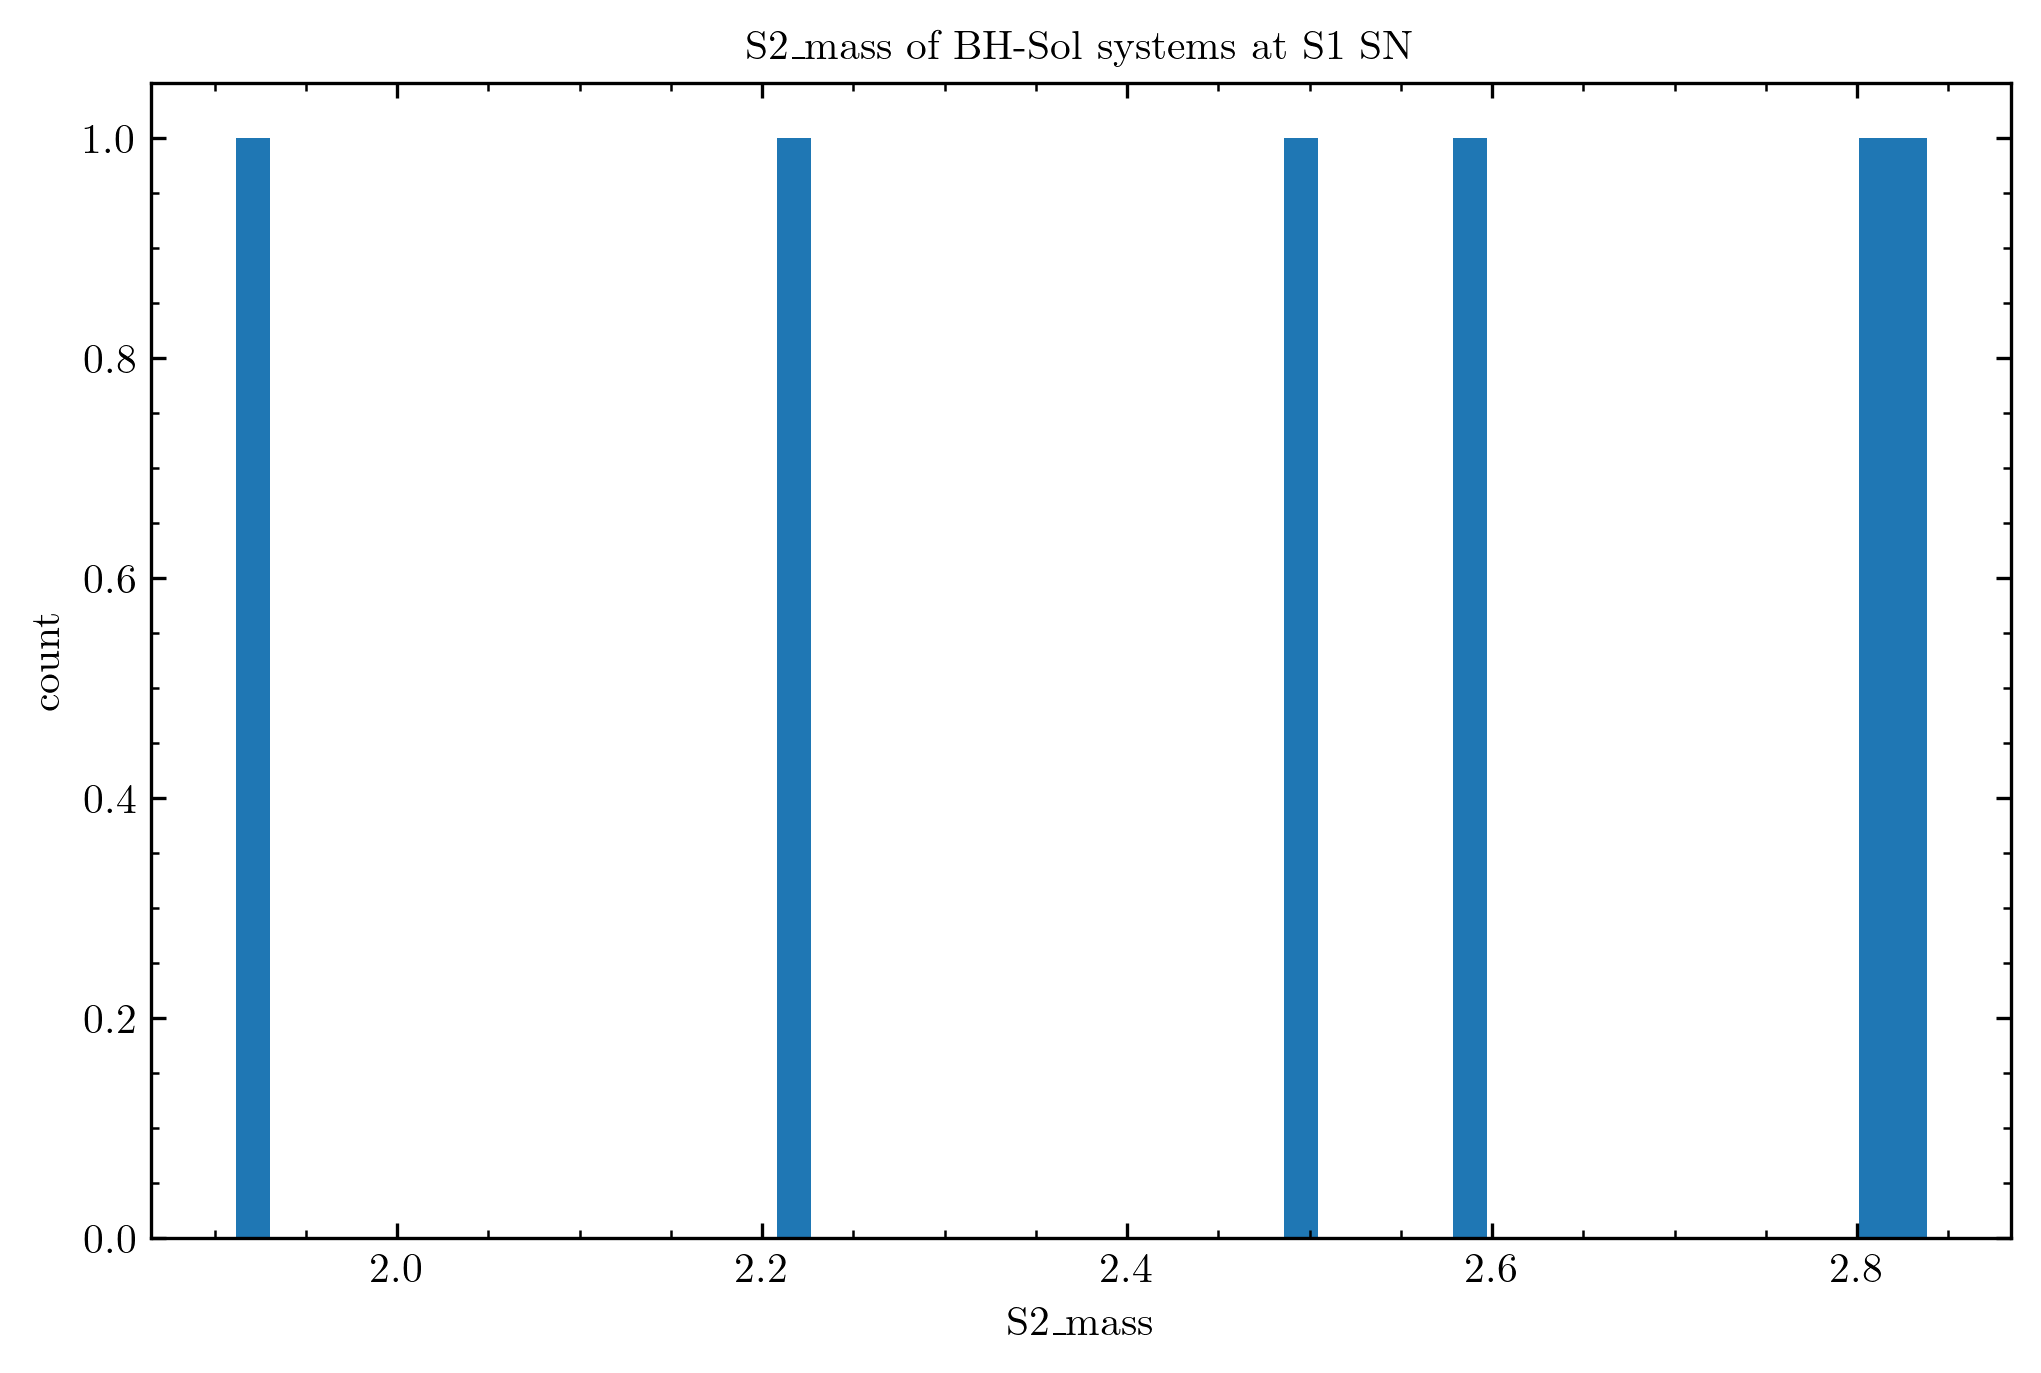

In [15]:
basicColHist(bhSolRows,'S2_mass')

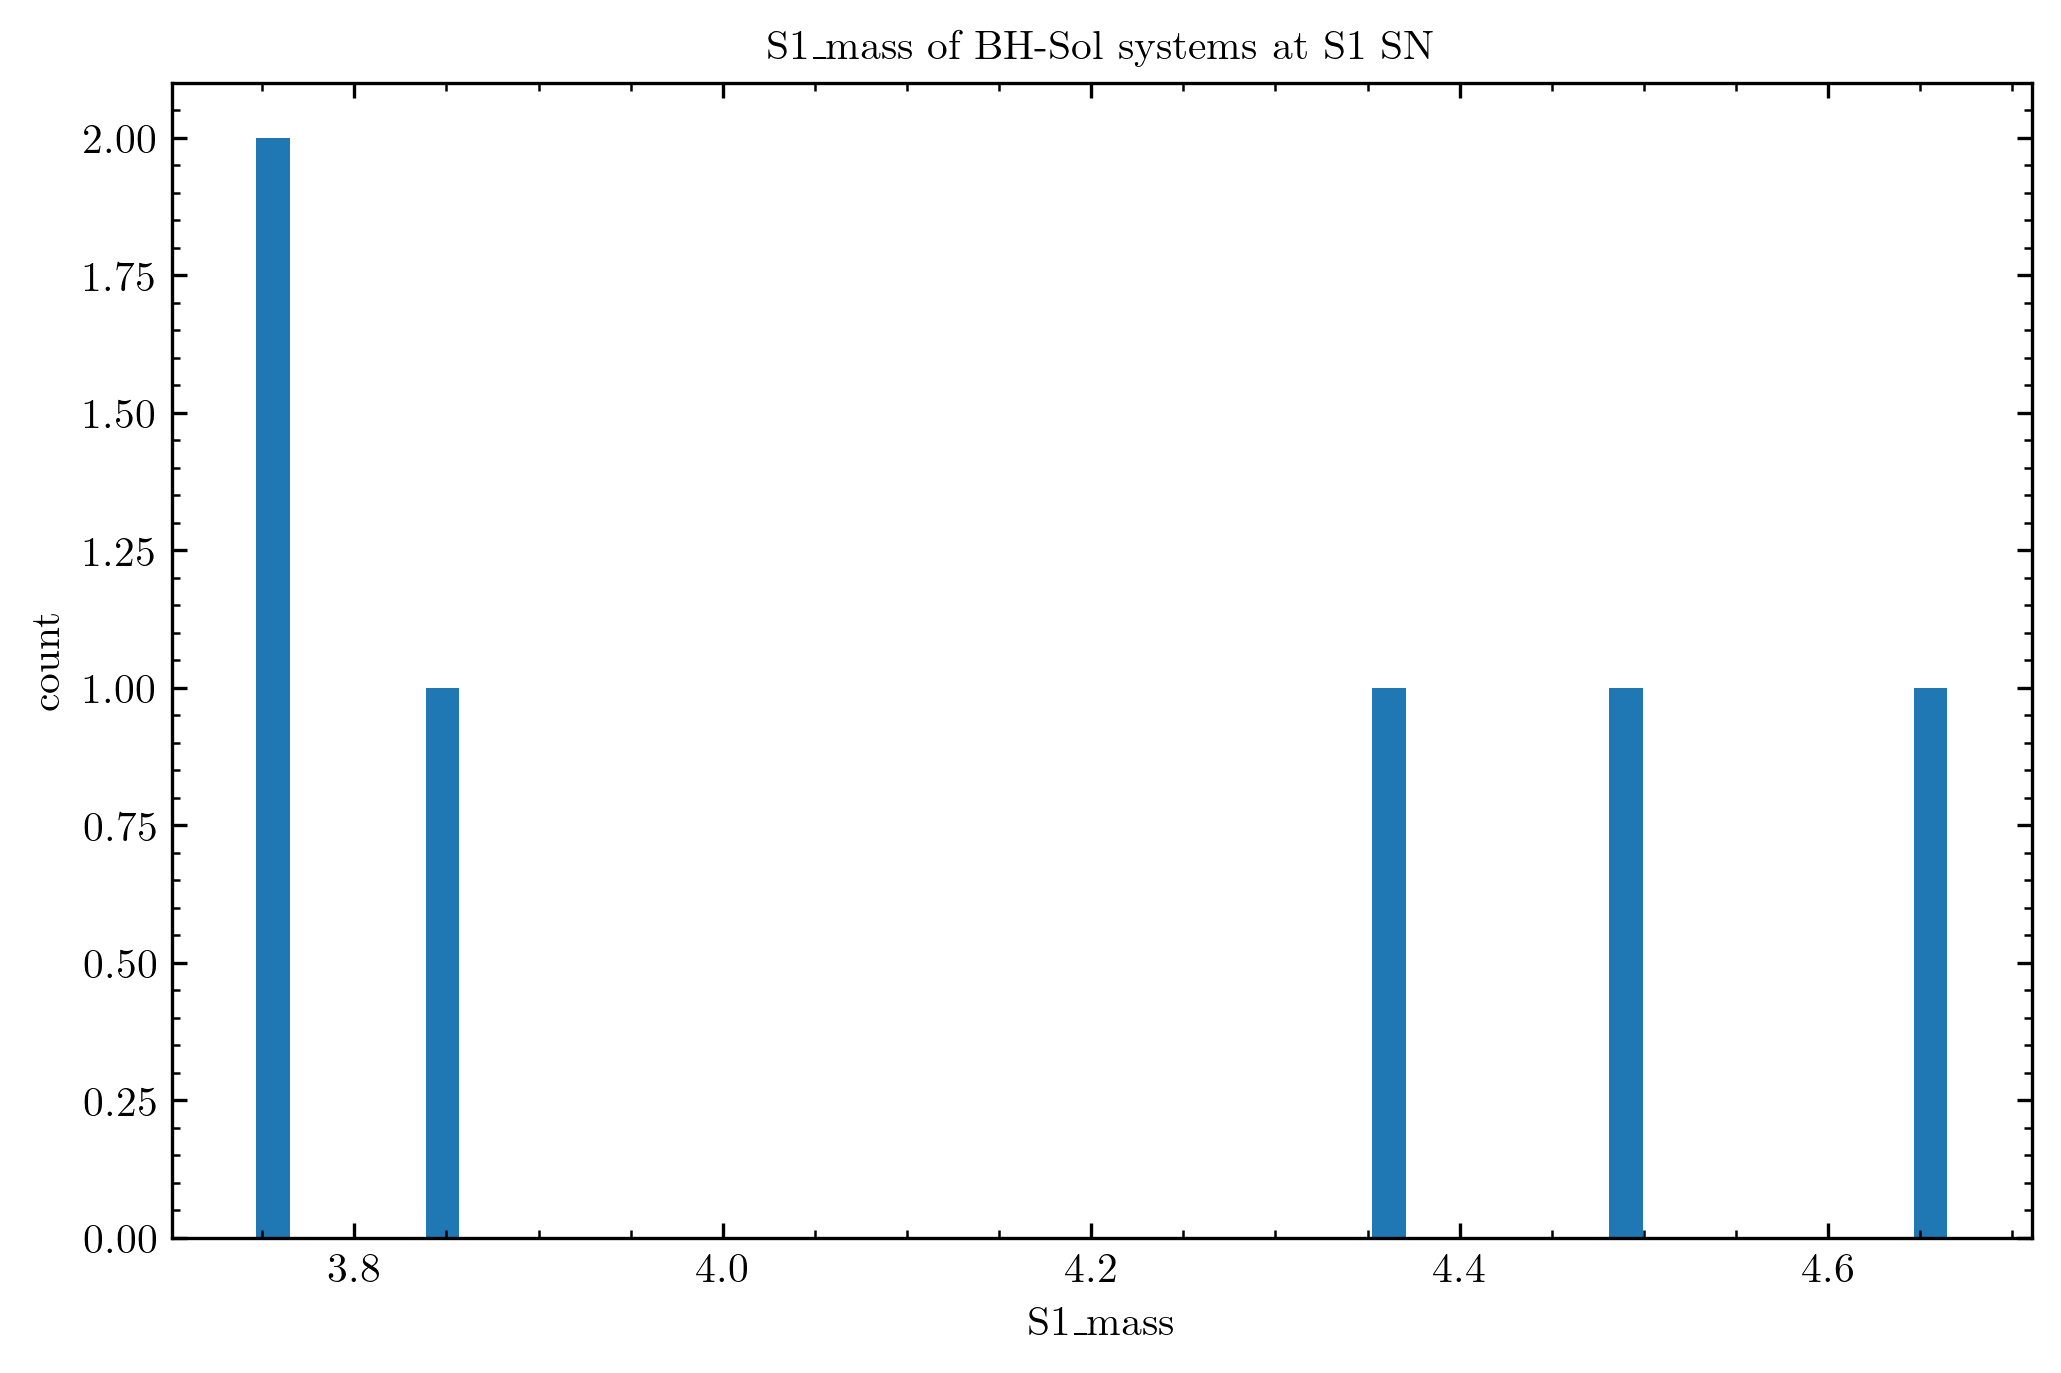

In [16]:
basicColHist(bhSolRows,'S1_mass')

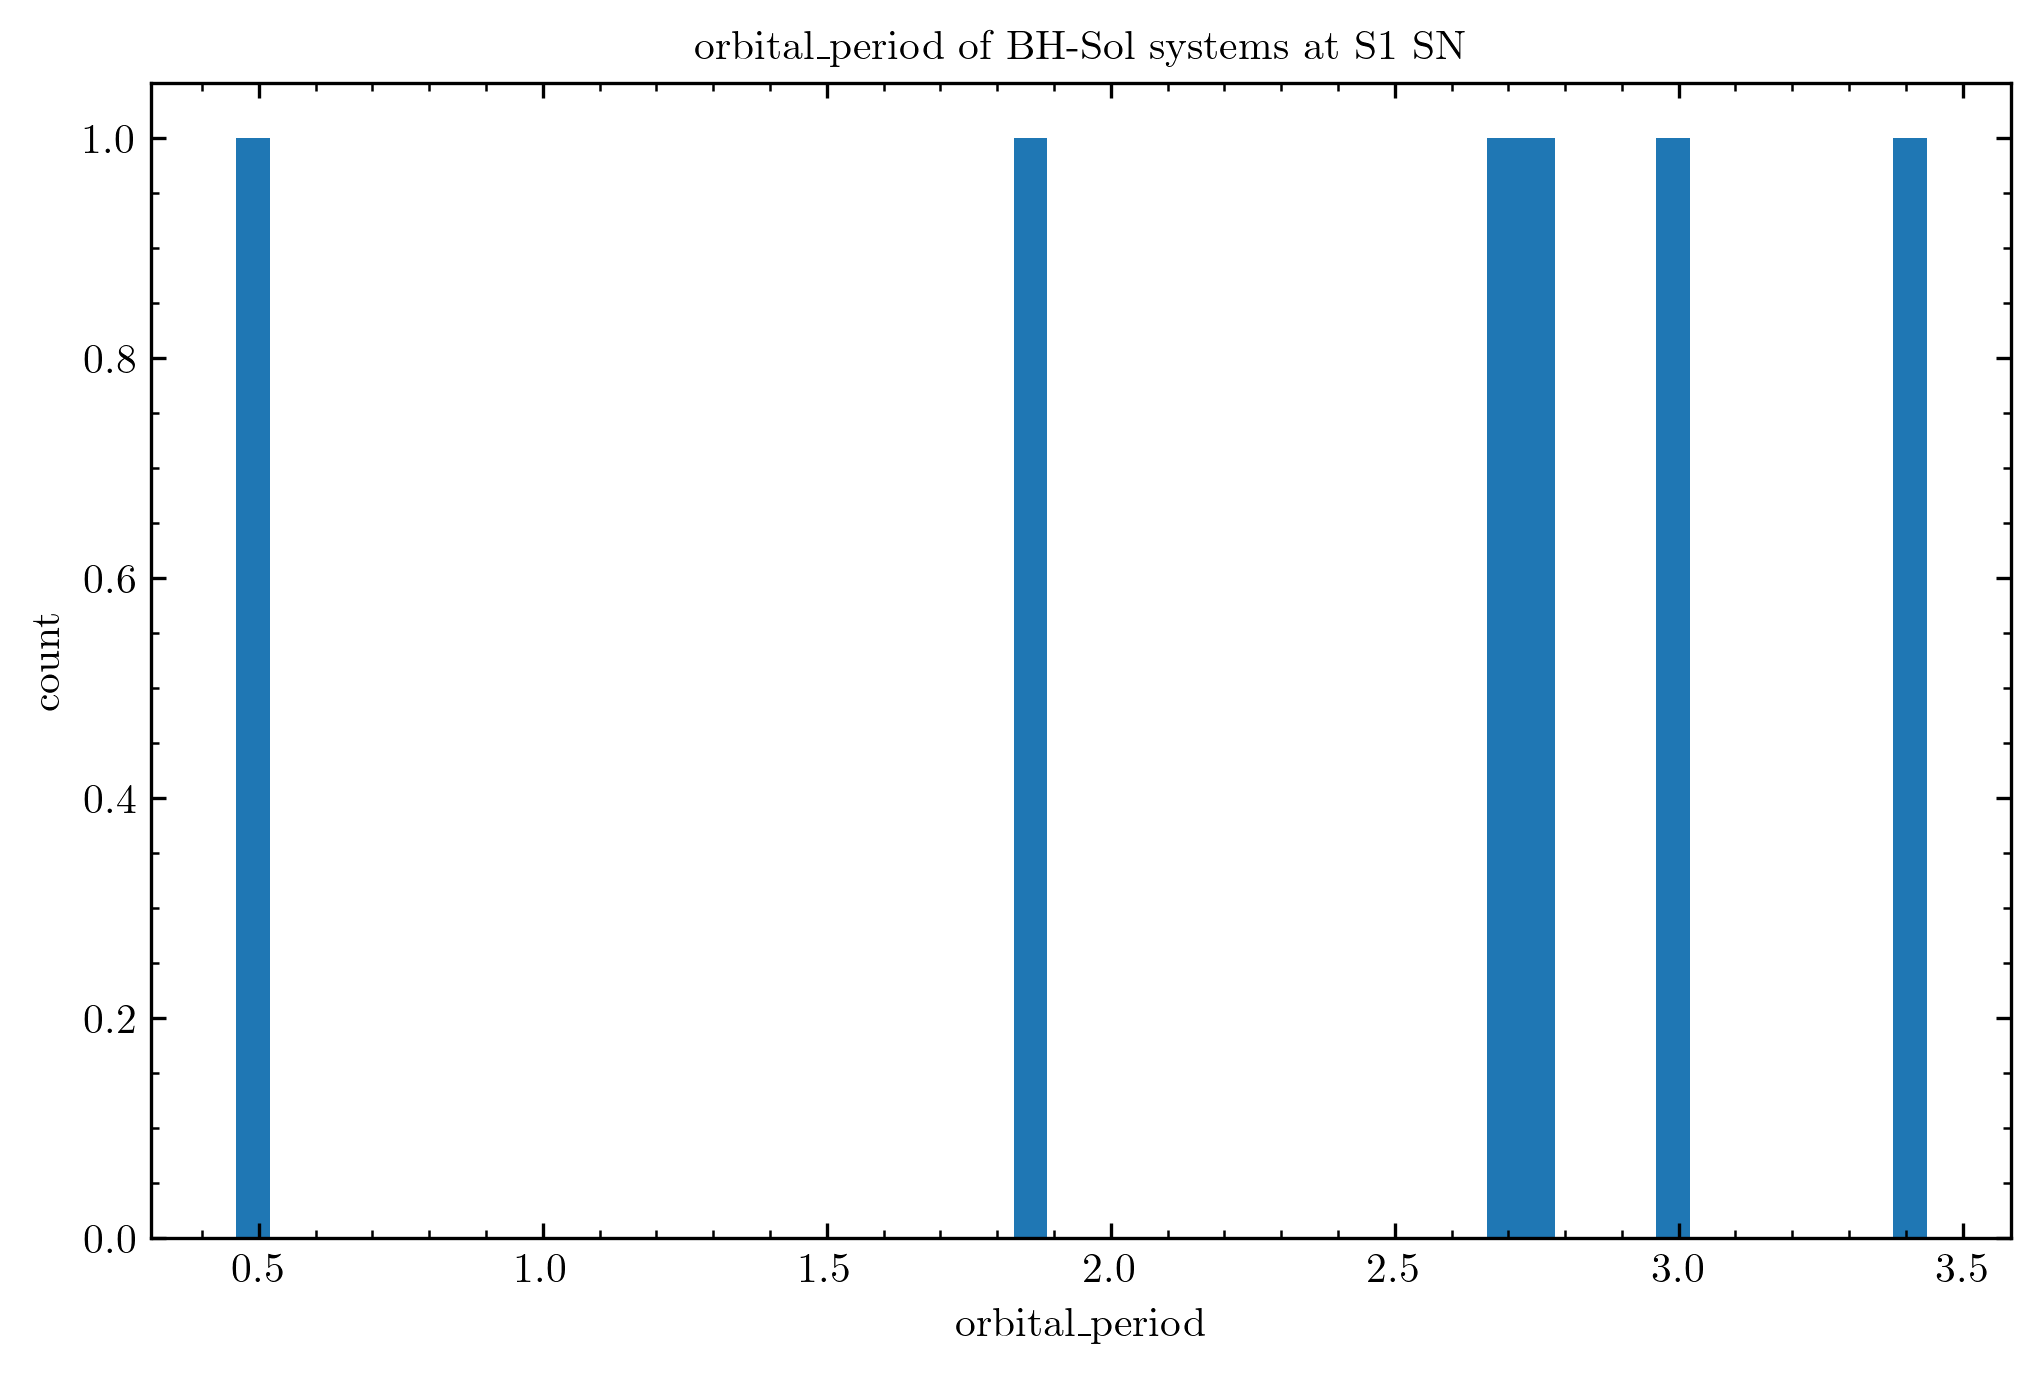

In [17]:
basicColHist(bhSolRows,'orbital_period', saveFig=True)


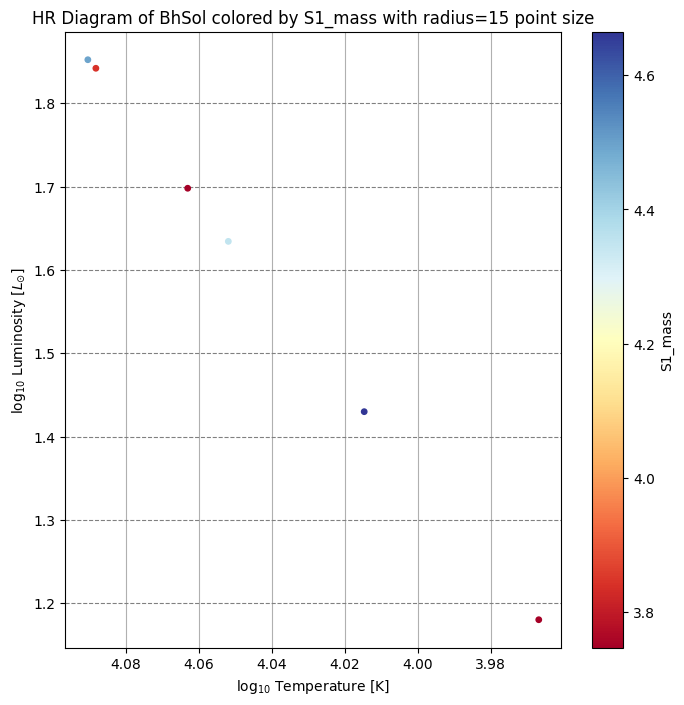

In [18]:
HR_Diagram(bhSolRows,
           'BhSol',
           Star_Radius=15)

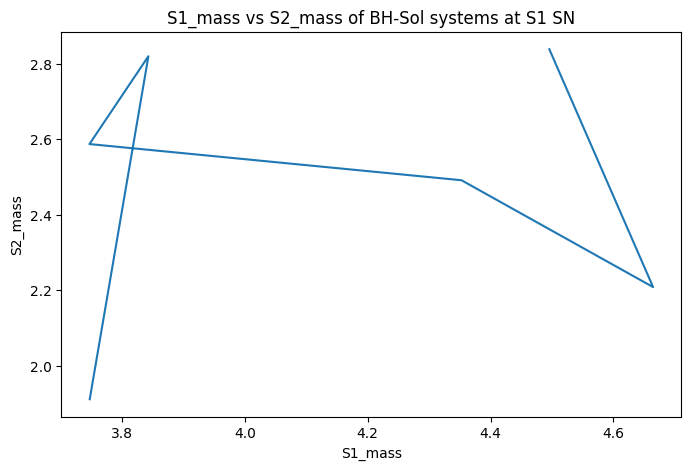

In [19]:
xVsY(bhSolRows, 'S1_mass', 'S2_mass')